In [1]:
#Library Imports
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


**Setup of dataset & AEV**

In [13]:
#Dataset initialization
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")

train_data, val_data, test_data = dataset.split(0.8, 0.1, None)

In [14]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


**Setting up training process, uses a trainer class which trains given training data and can also evaluate given test data.**

In [17]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        print(train_data_loader)
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for loaded_data in train_data_loader:
                
                # compute energies
                species = loaded_data['species'].to(device)
                coords = loaded_data['coordinates'].to(device)
                true_energies = loaded_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = len(species) / len(train_data)
                train_epoch_loss += batch_loss
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss.detach().cpu().item())
            val_loss_list.append(val_epoch_loss.detach().cpu().item())

            
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            x_axis = np.arange(self.epoch)
            ax.plot(x_axis, train_loss_list, label='Train')
            ax.plot(x_axis, val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return {
            "train_loss_list": train_loss_list,
            "val_loss_list": val_loss_list
        }
    
    
    def evaluate(self, data, draw_plot=False):
        self.model.eval()
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for loaded_data in data_loader:
                
                # compute energies
                species = loaded_data['species'].to(device)
                coords = loaded_data['coordinates'].to(device)
                true_energies = loaded_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)

                batch_importance = len(species) / len(data)
                total_loss += batch_loss
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

**My architecture for the neural network.** Neuron reduction from 384 -> 128 -> 128 -> 64 -> 64 -> 1. Inspired from the ANI-1 paper with my main configuration being a reduction in the input.

In [19]:
class miniNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64), 
            nn.ReLU(),
            nn.Linear(64, 1) )

    def forward(self, x):
        return self.layers(x)

net_H = miniNet()
net_C = miniNet()
net_N = miniNet()
net_O = miniNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
netmodel = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 296452
Initialize training data...


100%|████████████████████████████████████████████| 5/5 [18:19<00:00, 219.93s/it]


{'train_loss_list': [0.39470893144607544,
  0.052223771810531616,
  0.036659371107816696,
  0.028698936104774475,
  0.02403401955962181],
 'val_loss_list': [0.00601360434666276,
  0.006817672401666641,
  0.005055899731814861,
  0.002677007345482707,
  0.003856267547234893]}

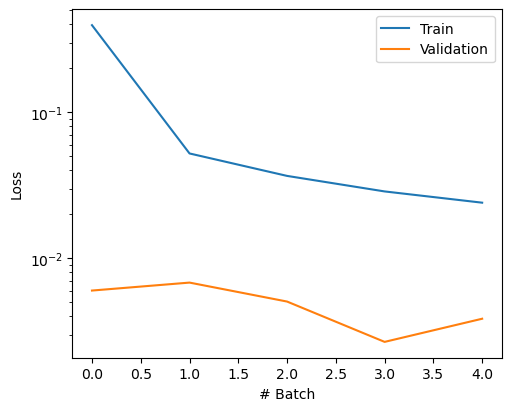

In [21]:
trainer = ANITrainer(model = netmodel, batch_size = 192, learning_rate = 0.001, epoch=5, l2=0.0)
training_loss = trainer.train(train_data, val_data)
training_loss

In [72]:
test_loss = trainer.evaluate(test_data)
test_loss

tensor(0.0012)

Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 5/5 [04:41<00:00, 56.25s/it]


([0.2863973379135132,
  0.01512226089835167,
  0.013702417723834515,
  0.012510042637586594,
  0.010813605971634388],
 [0.001734942547045648,
  0.0013365215854719281,
  0.0028332846704870462,
  0.002940070815384388,
  0.0026145637966692448])

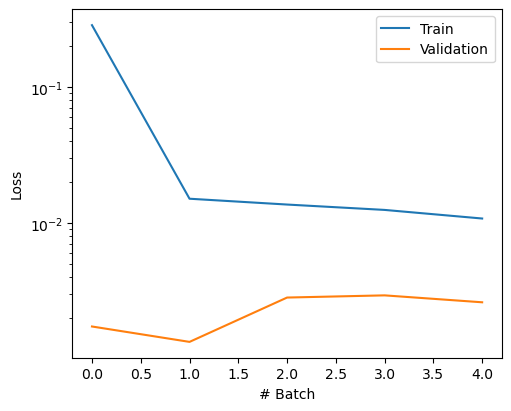

In [36]:
#increase in batch size & configuring linear layers to be more like paper
trainer = ANITrainer(model = netmodel, batch_size = 768, learning_rate = 0.001, epoch=5, l2=0.0)
training_loss = trainer.train(train_data, val_data)
training_loss

In [39]:
test_loss = trainer.evaluate(test_data)
test_loss

tensor(0.0026)

Higher batch size does not yield better results, this may be indicative that introducing training data in larger sets makes it harder for the model to generalize on the test data so invoking the model's ability to generalize is an important component of optimizing performance. Next step is to check if regularization will manage overfitting and produce better results than first two runs. 

Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 5/5 [04:40<00:00, 56.12s/it]


([0.12955179810523987,
  0.09723157435655594,
  0.09258540719747543,
  0.08809632807970047,
  0.08591841906309128],
 [0.011422337964177132,
  0.011475613340735435,
  0.012255214154720306,
  0.01044907420873642,
  0.011237040162086487])

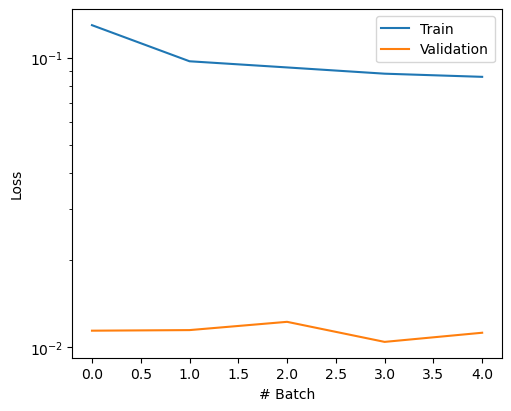

In [41]:
#Retaining same batch size as above (higher than first run) adding regularization 
trainer = ANITrainer(model = netmodel, batch_size = 768, learning_rate = 0.001, epoch=5, l2=1e-4)
training_loss = trainer.train(train_data, val_data)
training_loss

In [43]:
test_loss = trainer.evaluate(test_data)
test_loss

tensor(0.0109)

With regularization, the test & training loss is the highest out of all of the three model variations, indicating regularization is not effective in this model (it is diminishing weights that have a notable impact on the loss of the data.) So far, the first variation with a batch size of 384 and no regularization is the most effective. 

**Implementing K-Fold Cross Validation**

Using 3 folds

In [ ]:
def KFoldCrossValidation(
     k, 
    training_data, test_data,
    learning_rate=2e-3, batch_size=192, epoch=5, l2=0.0,
    early_break=False
):
    kf = KFold(n_splits=k, shuffle=True)
    batch_train_data = list(training_data)
    
    train_err_list, test_err_list, model_list = [], [], []
    for i, (train_index, val_index) in enumerate(kf.split(batch_train_data)):
        print(f"Fold {i}:")
        
        train_split = torchani.data.TransformableIterable([batch_train_data[i] for i in train_index])
        val_split = torchani.data.TransformableIterable([batch_train_data[i] for i in val_index])

        
        
        trainer = ANITrainer(netmodel, batch_size, learning_rate, epoch, l2)
        res = trainer.train(train_split, val_split)
        test_loss = trainer.evaluate(test_data)
        model_list.append(trainer)

        
        train_loss = res['train_loss_list']
        test_err_list.append(test_loss)
        train_err_list.append(train_loss)
        
        
        if early_break:
            break
    
    if not early_break:
        print("Final results:")
        print(f"Training error: {np.mean(train_err_list)}+/-{np.std(train_err_list)}")
        print(f"Testing error: {np.mean(test_err_list)}+/-{np.std(test_err_list)}")

    return model_list

Fold 0:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 5/5 [03:26<00:00, 41.35s/it]


Fold 1:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 5/5 [03:30<00:00, 42.04s/it]


Fold 2:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 5/5 [03:33<00:00, 42.62s/it]


Final results:
Training error: 0.021153558418154715+/-0.016027811114515577
Testing error: 0.002760974457487464+/-0.0006094184354878962


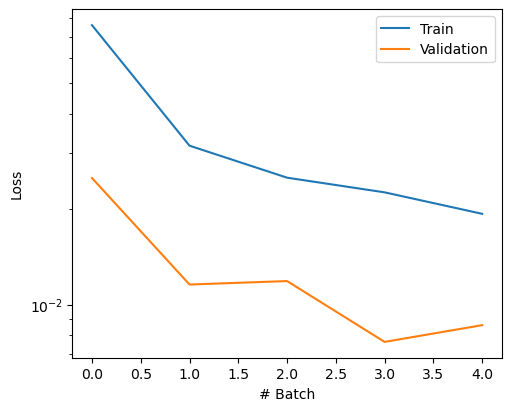

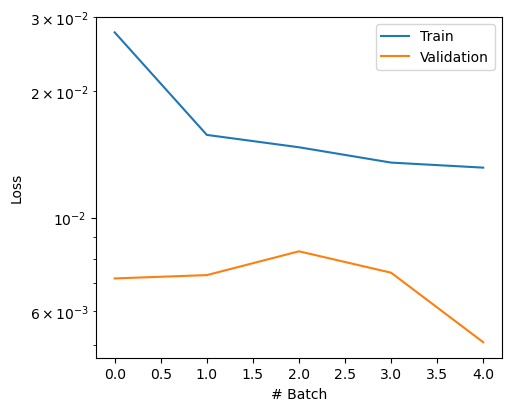

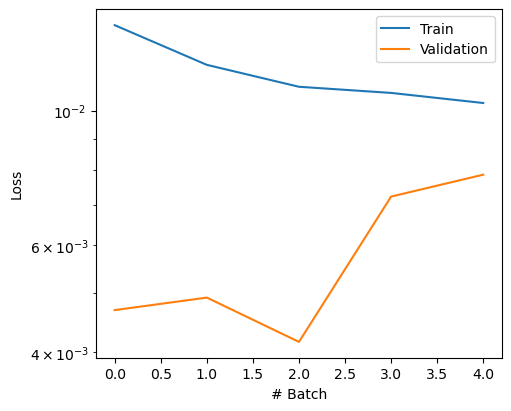

In [43]:
models = KFoldCrossValidation(3, train_data, test_data)

Fold 0:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 3/3 [02:19<00:00, 46.56s/it]


Fold 1:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 3/3 [02:23<00:00, 47.79s/it]


Fold 2:
Sequential - Number of parameters: 296452
Initialize training data...


100%|█████████████████████████████████████████████| 3/3 [02:31<00:00, 50.46s/it]


Final results:
Training error: 0.2051483415481117+/-0.4543514662353224
Testing error: 0.004106024280190468+/-0.0010029446566477418


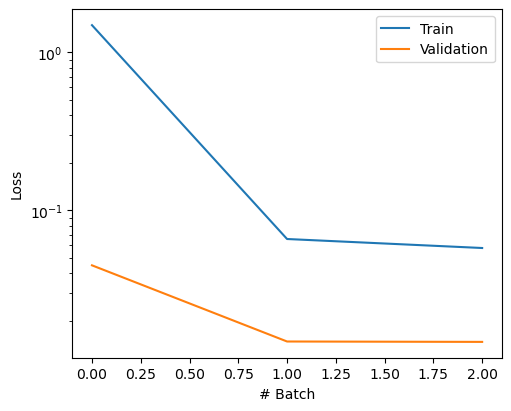

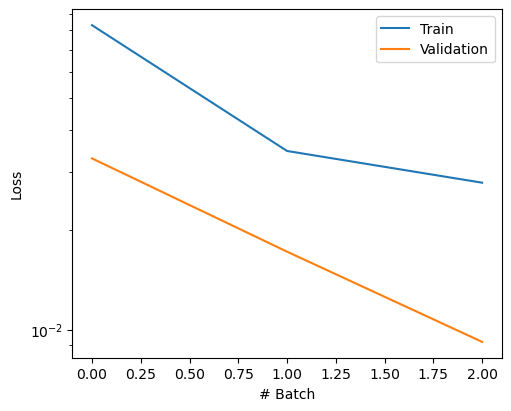

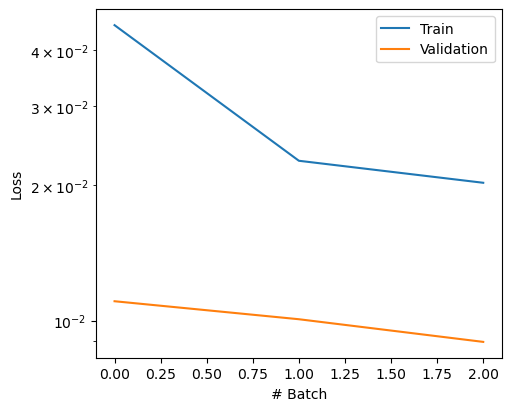

In [19]:
KFoldCrossValidation(3, train_data, test_data, epoch=3)

**Production Mode**: Scaling up to larger epochs but same model parameters.

In [15]:
#Dataset initialization
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")

final_train_data, final_val_data, final_test_data = dataset.split(0.6, 0.2, 0.2)

Sequential - Number of parameters: 296452
Initialize training data...


100%|███████████████████████████████████████████████████████████████| 50/50 [50:47<00:00, 60.96s/it]


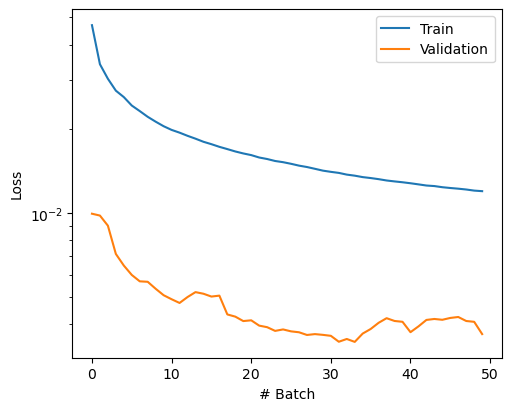

In [23]:
trainer = ANITrainer(model = netmodel, batch_size = 192, learning_rate = 0.001, epoch=50, l2=0.0)
training_loss = trainer.train(final_train_data, final_val_data)

tensor(0.0037)

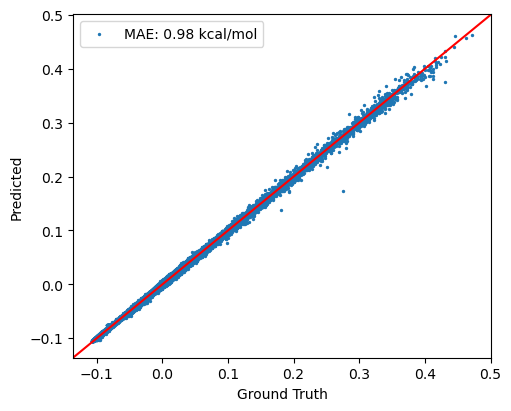

In [25]:
trainer.evaluate(final_test_data, draw_plot=True)

Comparing to the results in the paper, the researchers created a four layer neural network starting out at 768 input values. My architecture is similar except my neural network starts with 384 input values but has the same input -> 128 -> 128 -> 64 -> 1 neuron layering for the remainder of the layers. The researchers used Gaussian activations while I used a ReLU for every layer. The research model opted for the max norm regularization method while my model does not use regularization. Both models both opted for ADAM as the optimization method. Ultimately, the research model reports 1.3 kcal/mol for testing RMSE. Comparatively, I use MAE and I received results of 0.98kcal/mol, highlighting similar outcomes. However, I have a much higher parameter input as the research model reports 124,033 parameters while I have 296,452. 